# 1. Import and Install Dependencies

In [ ]:
!pip install tensorflow==2.14.1 opencv-python mediapipe scikit-learn matplotlib

In [4]:
import cv2
import numpy as np
import os
from matplotlib import pyplot as plt
import time
import mediapipe as mp
import json
import time
import tensorflow as tf

In [25]:
NOTEBOOK_DIR = os.path.dirname(os.path.abspath(''))  # Current notebooks/ directory
REPO_ROOT = os.path.dirname(NOTEBOOK_DIR)           # Go up one level to repo root

# Define all paths relative to repository root
MODEL_DIR = os.path.join(REPO_ROOT, 'data', 'models', 'production')
DATA_PATH = os.path.join(MODEL_DIR, 'MP_Data')
LOGS_PATH = os.path.join(MODEL_DIR, 'Logs')

# Ensure directories exist
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(DATA_PATH, exist_ok=True)
os.makedirs(LOGS_PATH, exist_ok=True)

# 2. Keypoints using MP Models

In [6]:
mp_pose = mp.solutions.pose
mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils

In [7]:
def mediapipe_detection(image, models):
    pose_model, hands_model = models
    rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    rgb_image.flags.writeable = False
    pose_results = pose_model.process(rgb_image)
    hands_results = hands_model.process(rgb_image)
    rgb_image.flags.writeable = True
    return image, (pose_results, hands_results)

In [8]:
def draw_landmarks(image, results):
    pose_results, hands_results = results
    mp_drawing.draw_landmarks(image, pose_results.pose_landmarks, mp_pose.POSE_CONNECTIONS)
    if hands_results.multi_hand_landmarks:
        for hand_landmarks in hands_results.multi_hand_landmarks:
            mp_drawing.draw_landmarks(image, hand_landmarks, mp_hands.HAND_CONNECTIONS)

In [9]:
def draw_styled_landmarks(image, results):
    pose_results, hands_results = results
    mp_drawing.draw_landmarks(
        image, pose_results.pose_landmarks, mp_pose.POSE_CONNECTIONS,
        mp_drawing.DrawingSpec(color=(80,22,10), thickness=2, circle_radius=4),
        mp_drawing.DrawingSpec(color=(80,44,121), thickness=2, circle_radius=2)
    )
    if hands_results.multi_hand_landmarks:
        for hand_landmarks in hands_results.multi_hand_landmarks:
            mp_drawing.draw_landmarks(
                image, hand_landmarks, mp_hands.HAND_CONNECTIONS,
                mp_drawing.DrawingSpec(color=(121,22,76), thickness=2, circle_radius=4),
                mp_drawing.DrawingSpec(color=(121,44,250), thickness=2, circle_radius=2)
            )

In [10]:
cap = cv2.VideoCapture(0)
pose_model = mp_pose.Pose(min_detection_confidence=0.5, min_tracking_confidence=0.5)
hands_model = mp_hands.Hands(max_num_hands=2, min_detection_confidence=0.5, min_tracking_confidence=0.5)
models = (pose_model, hands_model)

while cap.isOpened():
    ret, frame = cap.read()
    image, results = mediapipe_detection(frame, models)
    print(results)

    draw_styled_landmarks(image, results)

    cv2.imshow('OpenCV Feed', image)

    if cv2.waitKey(10) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

(<class 'mediapipe.python.solution_base.SolutionOutputs'>, <class 'mediapipe.python.solution_base.SolutionOutputs'>)
(<class 'mediapipe.python.solution_base.SolutionOutputs'>, <class 'mediapipe.python.solution_base.SolutionOutputs'>)
(<class 'mediapipe.python.solution_base.SolutionOutputs'>, <class 'mediapipe.python.solution_base.SolutionOutputs'>)
(<class 'mediapipe.python.solution_base.SolutionOutputs'>, <class 'mediapipe.python.solution_base.SolutionOutputs'>)
(<class 'mediapipe.python.solution_base.SolutionOutputs'>, <class 'mediapipe.python.solution_base.SolutionOutputs'>)
(<class 'mediapipe.python.solution_base.SolutionOutputs'>, <class 'mediapipe.python.solution_base.SolutionOutputs'>)
(<class 'mediapipe.python.solution_base.SolutionOutputs'>, <class 'mediapipe.python.solution_base.SolutionOutputs'>)
(<class 'mediapipe.python.solution_base.SolutionOutputs'>, <class 'mediapipe.python.solution_base.SolutionOutputs'>)
(<class 'mediapipe.python.solution_base.SolutionOutputs'>, <clas

In [11]:
draw_landmarks(frame, results)

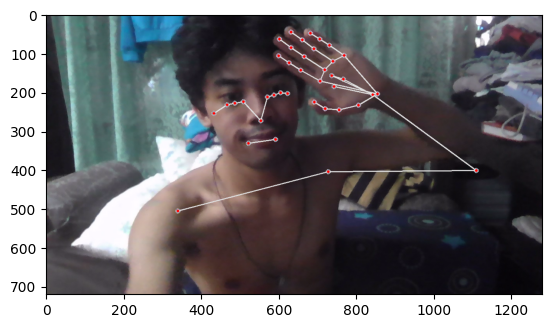

In [12]:
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

# 3. Extract Keypoint Values

In [13]:
pose_results, hands_results = results
len(hands_results.multi_hand_landmarks[0].landmark) if hands_results.multi_hand_landmarks else 0

21

In [14]:
pose_results, hands_results = results

pose = np.array([[r.x, r.y, r.z, r.visibility] for r in pose_results.pose_landmarks.landmark]).flatten() \
    if pose_results.pose_landmarks else np.zeros(132)

lh = np.zeros(21*3)
rh = np.zeros(21*3)
if hands_results.multi_hand_landmarks:
    for landmarks, handedness in zip(hands_results.multi_hand_landmarks, hands_results.multi_handedness):
        coords = np.array([[r.x, r.y, r.z] for r in landmarks.landmark]).flatten()
        if handedness.classification[0].label == 'Left':
            lh = coords
        else:
            rh = coords

In [15]:
def extract_keypoints(results):
    pose_results, hands_results = results

    pose = np.array([[r.x, r.y, r.z, r.visibility] for r in pose_results.pose_landmarks.landmark]).flatten() \
        if pose_results.pose_landmarks else np.zeros(33*4)

    lh = np.zeros(21*3)
    rh = np.zeros(21*3)
    if hands_results.multi_hand_landmarks:
        for landmarks, handedness in zip(hands_results.multi_hand_landmarks, hands_results.multi_handedness):
            coords = np.array([[r.x, r.y, r.z] for r in landmarks.landmark]).flatten()
            if handedness.classification[0].label == 'Left':
                lh = coords
            else:
                rh = coords

    return np.concatenate([pose, lh, rh])

In [16]:
result_test = extract_keypoints(results)

In [17]:
result_test

array([ 4.33287948e-01,  3.81825894e-01, -7.06340194e-01,  9.99987125e-01,
        4.46252257e-01,  2.95991570e-01, -6.47039294e-01,  9.99971628e-01,
        4.60017771e-01,  2.88903683e-01, -6.46746516e-01,  9.99965906e-01,
        4.72997099e-01,  2.81758577e-01, -6.46603167e-01,  9.99959409e-01,
        3.97698104e-01,  3.13344419e-01, -6.70244396e-01,  9.99980032e-01,
        3.80736798e-01,  3.18183303e-01, -6.69929028e-01,  9.99979436e-01,
        3.65436316e-01,  3.23640496e-01, -6.69999361e-01,  9.99981403e-01,
        4.86922741e-01,  2.84469724e-01, -3.12150180e-01,  9.99972701e-01,
        3.38344038e-01,  3.55545878e-01, -4.09153372e-01,  9.99993086e-01,
        4.62689817e-01,  4.47547227e-01, -5.79106033e-01,  9.99980748e-01,
        4.08492982e-01,  4.61661488e-01, -6.05137408e-01,  9.99990702e-01,
        5.68920493e-01,  5.63129365e-01, -1.04430571e-01,  9.99739945e-01,
        2.66135812e-01,  7.03192711e-01, -2.40805954e-01,  9.99352694e-01,
        8.67769361e-01,  

In [18]:
np.save(os.path.join(MODEL_DIR, '0'), result_test)

In [19]:
np.load(os.path.join(MODEL_DIR, '0.npy'))

array([ 4.33287948e-01,  3.81825894e-01, -7.06340194e-01,  9.99987125e-01,
        4.46252257e-01,  2.95991570e-01, -6.47039294e-01,  9.99971628e-01,
        4.60017771e-01,  2.88903683e-01, -6.46746516e-01,  9.99965906e-01,
        4.72997099e-01,  2.81758577e-01, -6.46603167e-01,  9.99959409e-01,
        3.97698104e-01,  3.13344419e-01, -6.70244396e-01,  9.99980032e-01,
        3.80736798e-01,  3.18183303e-01, -6.69929028e-01,  9.99979436e-01,
        3.65436316e-01,  3.23640496e-01, -6.69999361e-01,  9.99981403e-01,
        4.86922741e-01,  2.84469724e-01, -3.12150180e-01,  9.99972701e-01,
        3.38344038e-01,  3.55545878e-01, -4.09153372e-01,  9.99993086e-01,
        4.62689817e-01,  4.47547227e-01, -5.79106033e-01,  9.99980748e-01,
        4.08492982e-01,  4.61661488e-01, -6.05137408e-01,  9.99990702e-01,
        5.68920493e-01,  5.63129365e-01, -1.04430571e-01,  9.99739945e-01,
        2.66135812e-01,  7.03192711e-01, -2.40805954e-01,  9.99352694e-01,
        8.67769361e-01,  

# 4. Setup Folders for Collection

In [ ]:
# If data needed to be re-recorded and new
shutil.rmtree(DATA_PATH, ignore_errors=True)

In [20]:
# Actions that we try to detect
actions = np.array([
    'kamusta', 'salamat', 'mahalkita', 'oo', 'hindi',
    'sino', 'saan', 'ulitin', 'please', 'paalam',
    'tulong', 'walang_anuman', 'ingat', 'gusto', 'hindi_gusto',
    'tulog', 'masaya', 'takot', 'CR', 'pera',
    'ina', 'ama'
])

# Thirty videos worth of data
no_sequences = 60

# Videos are going to be 30 frames in length
sequence_length = 30

# Folder start
start_folder = 0

In [21]:
for action in actions:
    action_path = os.path.join(DATA_PATH, action)
    for sequence in range(no_sequences):
        os.makedirs(os.path.join(action_path, str(sequence)), exist_ok=True)

# 5. Collect Keypoint Values for Training and Testing

In [ ]:
def record_action(action, cap, models):
    for sequence in range(no_sequences):
        for frame_num in range(sequence_length):
            ret, frame = cap.read()
            image, results = mediapipe_detection(frame, models)   
            draw_styled_landmarks(image, results)

            if frame_num == 0:
                cv2.putText(image, 'STARTING COLLECTION', (120, 200),
                            cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 4, cv2.LINE_AA)
                cv2.putText(image, 'Collecting frames for {} Video Number {}'.format(action, sequence), (15, 12),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1, cv2.LINE_AA)
                cv2.imshow('OpenCV Feed', image)
                cv2.waitKey(2000)
            else:
                cv2.putText(image, 'Collecting frames for {} Video Number {}'.format(action, sequence), (15, 12),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1, cv2.LINE_AA)
                cv2.imshow('OpenCV Feed', image)

            keypoints = extract_keypoints(results)
            sequence_dir = os.path.join(DATA_PATH, action, str(sequence))
            os.makedirs(sequence_dir, exist_ok=True)
            npy_path = os.path.join(sequence_dir, str(frame_num))
            np.save(npy_path, keypoints)

            key = cv2.waitKey(10) & 0xFF

            if key == ord('e'):
                while True:
                    ret, pause_frame = cap.read()
                    cv2.putText(pause_frame, 'PAUSED - press E to resume', (60, 240),
                                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 165, 255), 3, cv2.LINE_AA)
                    cv2.imshow('OpenCV Feed', pause_frame)
                    resume_key = cv2.waitKey(10) & 0xFF
                    if resume_key == ord('e'):
                        break
                    if resume_key == ord('q'):
                        return "stopped"

                for countdown in range(5, 0, -1):
                    ret, cd_frame = cap.read()
                    cv2.putText(cd_frame, f'Resuming in {countdown}...', (100, 240),
                                cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 255, 0), 3, cv2.LINE_AA)
                    cv2.imshow('OpenCV Feed', cd_frame)
                    cv2.waitKey(1000)

            if key == ord('q'):
                return "stopped"

    return "done"

In [ ]:
cap = cv2.VideoCapture(0)
pose_model = mp_pose.Pose(min_detection_confidence=0.5, min_tracking_confidence=0.5)
hands_model = mp_hands.Hands(max_num_hands=2, min_detection_confidence=0.5, min_tracking_confidence=0.5)
models = (pose_model, hands_model)

In [ ]:
record_action('kamusta', cap, models)

In [ ]:
record_action('salamat', cap, models)

In [ ]:
record_action('mahalkita', cap, models)

In [ ]:
record_action('oo', cap, models)

In [ ]:
record_action('hindi', cap, models)

In [ ]:
record_action('sino', cap, models)

In [ ]:
record_action('saan', cap, models)

In [ ]:
record_action('ulitin', cap, models)

In [ ]:
record_action('please', cap, models)

In [ ]:
record_action('paalam', cap, models)

In [ ]:
record_action('tulong', cap, models)

In [ ]:
record_action('walang_anuman', cap, models)

In [ ]:
record_action('ingat', cap, models)

In [ ]:
record_action('gusto', cap, models)

In [ ]:
record_action('hindi_gusto', cap, models)

In [ ]:
record_action('tulog', cap, models)

In [ ]:
record_action('masaya', cap, models)

In [ ]:
record_action('takot', cap, models)

In [ ]:
record_action('CR', cap, models)

In [ ]:
record_action('pera', cap, models)

In [ ]:
record_action('nanay', cap, models)

In [ ]:
record_action('tatay', cap, models)

In [ ]:
pose_model.close()
hands_model.close()
cap.release()
cv2.destroyAllWindows()

# 6. Preprocess Data and Create Labels and Features

In [22]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

In [23]:
label_map = {label:num for num, label in enumerate(actions)}

In [24]:
label_map

{'kamusta': 0,
 'salamat': 1,
 'mahalkita': 2,
 'oo': 3,
 'hindi': 4,
 'sino': 5,
 'saan': 6,
 'ulitin': 7,
 'please': 8,
 'paalam': 9,
 'tulong': 10,
 'walang_anuman': 11,
 'ingat': 12,
 'gusto': 13,
 'hindi_gusto': 14,
 'tulog': 15,
 'masaya': 16,
 'takot': 17,
 'CR': 18,
 'pera': 19,
 'ina': 20,
 'ama': 21}

In [ ]:
sequences, labels = [], []
for action in actions:
    for sequence in range(no_sequences):
        window = []
        for frame_num in range(sequence_length):
            res = np.load(os.path.join(DATA_PATH, action, str(sequence), "{}.npy".format(frame_num)))
            window.append(res)
        sequences.append(window)
        labels.append(label_map[action])

In [26]:
np.array(sequences).shape

NameError: name 'sequences' is not defined

In [ ]:
np.array(labels).shape

In [ ]:
X = np.array(sequences)

In [ ]:
X.shape

In [ ]:
y = to_categorical(labels).astype(int)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
y_test.shape

# 7. Build and Train LSTM Neural Network

In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping

In [31]:
log_dir = os.path.join('Logs')
tb_callback = TensorBoard(log_dir=log_dir)
early_stop = EarlyStopping(monitor='val_categorical_accuracy', patience=100, restore_best_weights=True)

In [32]:
model = Sequential()
model.add(LSTM(64, return_sequences=True, activation='relu', input_shape=(30,258)))
model.add(Dropout(0.3))
model.add(LSTM(128, return_sequences=True, activation='relu'))
model.add(Dropout(0.3))
model.add(LSTM(64, return_sequences=False, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(actions.shape[0], activation='softmax'))

In [33]:
model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['categorical_accuracy'])

In [ ]:
model.fit(X_train, y_train, epochs=2000, validation_data=(X_test, y_test), callbacks=[tb_callback, early_stop])

In [ ]:
model.summary()

# 8. Make Predictions

In [34]:
res = model.predict(X_test)

NameError: name 'X_test' is not defined

In [ ]:
actions[np.argmax(res[0])]

In [ ]:
actions[np.argmax(y_test[0])]

# 9. Save Weights

In [35]:
model.save(os.path.join(MODEL_DIR, 'action.h5'))
model.save(os.path.join(MODEL_DIR, 'action.keras'))

C:\Users\user\anaconda3\envs\tensorflow_2\lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [36]:

with open(os.path.join(MODEL_DIR, 'labels.json'), 'w') as f:
    json.dump(actions.tolist(), f)
    
config = {
    "sequence_length": sequence_length,
    "num_features": 258,
    "threshold": 0.7
}
with open(os.path.join(MODEL_DIR, 'config.json'), 'w') as f:
    json.dump(config, f)

In [ ]:
del model

In [38]:
model.load_weights(os.path.join(MODEL_DIR, 'action.h5'))

# 10. Evaluation using Confusion Matrix and Accuracy

In [ ]:
from sklearn.metrics import multilabel_confusion_matrix, accuracy_score

In [ ]:
yhat = model.predict(X_train)

In [ ]:
ytrue = np.argmax(y_train, axis=1).tolist()
yhat = np.argmax(yhat, axis=1).tolist()

In [ ]:
multilabel_confusion_matrix(ytrue, yhat)

In [ ]:
accuracy_score(ytrue, yhat)

# 11. Test in Real Time

In [ ]:
from scipy import stats

In [ ]:
colors = [(245,117,16), (117,245,16), (16,117,245)]

res = res.flatten()

def prob_viz(res, actions, input_frame, colors):
    output_frame = input_frame.copy()
    # Clip loop to the shortest length to avoid index errors
    for num, prob in enumerate(res[:len(actions)]):
        cv2.rectangle(
            output_frame,
            (0, 60 + num*40),
            (int(prob * 100), 90 + num*40),
            colors[num % len(colors)],  # cycle colors if fewer than actions
            -1
        )
        cv2.putText(
            output_frame,
            actions[num],
            (0, 85 + num*40),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (255,255,255),
            2,
            cv2.LINE_AA
        )
    return output_frame

In [ ]:
plt.figure(figsize=(18,18))
plt.imshow(prob_viz(res, actions, image, colors))

In [ ]:
sequence = []
sentence = []
predictions = []
threshold = 0.7

cap = cv2.VideoCapture(0)

# Set MediaPipe model
pose_model = mp_pose.Pose(
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

hands_model = mp_hands.Hands(
    max_num_hands=2,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

models = (pose_model, hands_model)

while cap.isOpened():
    ret, frame = cap.read()

    image, results = mediapipe_detection(frame, models)
    print(results)

    # Draw landmarks
    draw_styled_landmarks(image, results)

    # 2. Prediction logic
    keypoints = extract_keypoints(results)
    sequence.append(keypoints)
    sequence = sequence[-30:]

    if len(sequence) == 30:
        res = model.predict(
            np.expand_dims(sequence, axis=0)
        )[0]

        print(actions[np.argmax(res)])
        predictions.append(np.argmax(res))

        # 3. Viz logic
        if np.unique(predictions[-10:])[0] == np.argmax(res):
            if res[np.argmax(res)] > threshold:

                if len(sentence) > 0:
                    if actions[np.argmax(res)] != sentence[-1]:
                        sentence.append(actions[np.argmax(res)])
                else:
                    sentence.append(actions[np.argmax(res)])

        if len(sentence) > 5:
            sentence = sentence[-5:]

        # Viz probabilities
        image = prob_viz(
            res,
            actions,
            image,
            colors
        )

    cv2.rectangle(
        image,
        (0, 0),
        (640, 40),
        (245, 117, 16),
        -1
    )

    cv2.putText(
        image,
        ' '.join(sentence),
        (3, 30),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (255, 255, 255),
        2,
        cv2.LINE_AA
    )

    # Show to screen
    cv2.imshow('OpenCV Feed', image)

    # Break gracefully
    if cv2.waitKey(10) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

In [ ]:
test_model = tf.keras.models.load_model('action.h5')
test_model.summary()

dummy_input = np.random.rand(1, 30, 258).astype('float32')
prediction = test_model.predict(dummy_input)
print(prediction)
print(actions[np.argmax(prediction)])